In [ ]:
E:\Final Project\Final_Dataset\skin\stage2_disease_classification\train

In [1]:
import os
print(os.listdir(r"E:\Final Project\Final_Dataset\skin\stage2_disease_classification\train"))


['Akne', 'Benign', 'Ekzama', 'Enfeksiyonel', 'Malign', 'Pigment']


Classes: ['Akne', 'Benign', 'Ekzama', 'Enfeksiyonel', 'Malign', 'Pigment']
Total images in TRAIN: 17280


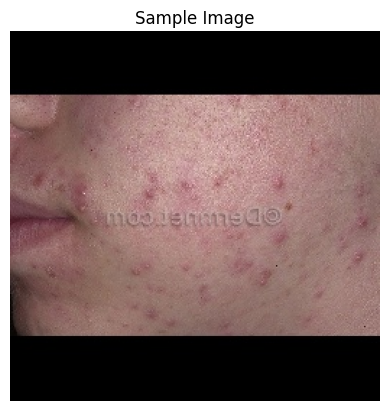

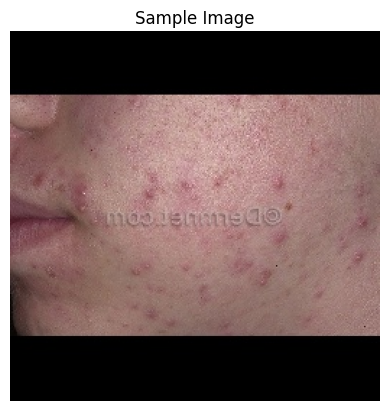

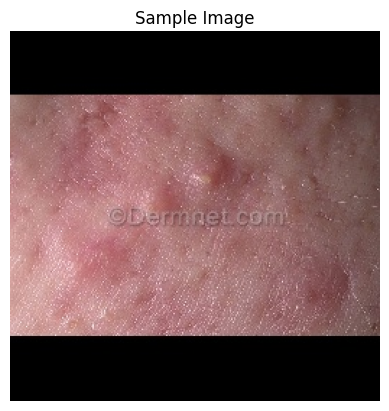

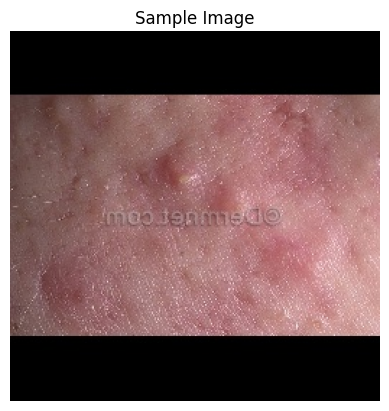

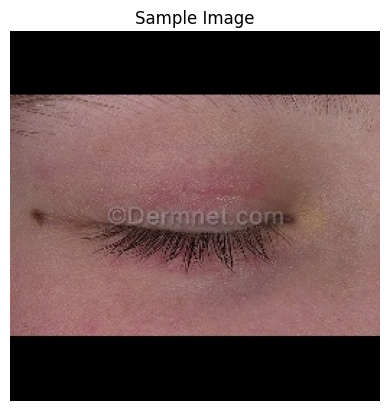

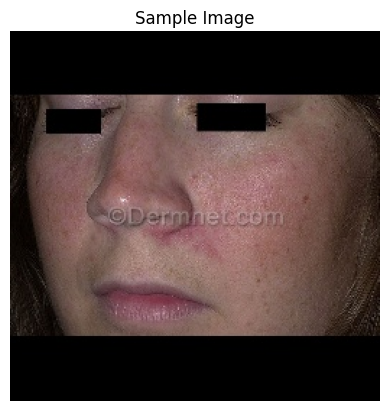

Brightness Mean: 83.38226768493652
Brightness Std: 17.863097818924604
Min Brightness: 28.968429565429688
Max Brightness: 133.15426635742188


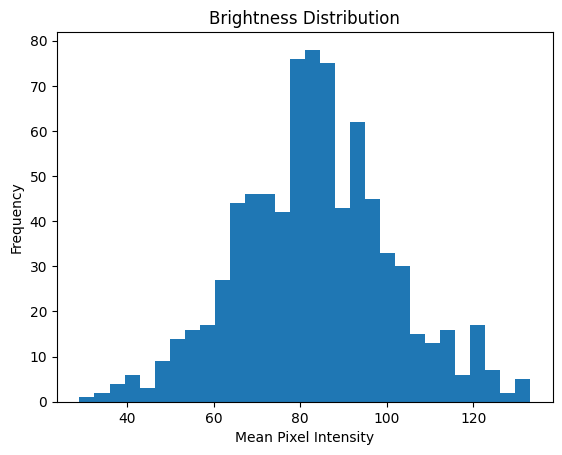

In [3]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

BASE_PATH = r"E:\Final Project\Final_Dataset\skin\stage2_disease_classification\train"

classes = os.listdir(BASE_PATH)
print("Classes:", classes)

all_image_paths = []

for cls in classes:
    class_folder = os.path.join(BASE_PATH, cls)
    for file in os.listdir(class_folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            all_image_paths.append(os.path.join(class_folder, file))

print("Total images in TRAIN:", len(all_image_paths))

# Show 6 sample images
for i in range(6):
    img = Image.open(all_image_paths[i]).resize((256, 256))
    plt.figure()
    plt.imshow(img)
    plt.title("Sample Image")
    plt.axis("off")
    plt.show()

# Brightness analysis
brightness_values = []

for path in all_image_paths[:800]:
    img = Image.open(path).convert("L").resize((256, 256))
    img_array = np.array(img)
    brightness_values.append(np.mean(img_array))

brightness_values = np.array(brightness_values)

print("Brightness Mean:", np.mean(brightness_values))
print("Brightness Std:", np.std(brightness_values))
print("Min Brightness:", np.min(brightness_values))
print("Max Brightness:", np.max(brightness_values))

plt.figure()
plt.hist(brightness_values, bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


In [7]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [48]:
# FINAL CORRECT TRAINING WORKFLOW (7 Classes, Stable)
# 🔹 1️⃣ Config
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input

BASE_PATH = r"E:\Final Project\Final_Dataset\skin\stage2_disease_classification"

WEIGHTS_PATH = "skin7_best_weights.h5"
FINAL_MODEL_PATH = "skin7_best_model.keras"
FINAL_MODEL_PATH_H5 = "skin7_best_model.h5"
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 12
AUTOTUNE = tf.data.AUTOTUNE



In [26]:
# 🔹 2️⃣ Load Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 20160 files belonging to 7 classes.
Found 2520 files belonging to 7 classes.
Classes: ['Akne', 'Benign', 'Ekzama', 'Enfeksiyonel', 'Healthy', 'Malign', 'Pigment']


In [27]:
# 3️⃣ Augmentation + Preprocessing
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(preprocess_input(x), training=True),
        tf.one_hot(y, depth=num_classes)
    ),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (
        preprocess_input(x),
        tf.one_hot(y, depth=num_classes)
    ),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)




In [30]:
# 🔹 4️⃣ Build Model
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = True

for layer in base_model.layers[:-70]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(256, 256, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)


In [31]:
# 🔹 5️⃣ Resume From Checkpoint (if exists)
if os.path.exists(WEIGHTS_PATH):
    print("🔄 Loading existing weights...")
    model.load_weights(WEIGHTS_PATH)
    print("✅ Resumed from checkpoint.")
else:
    print("🆕 Starting fresh training.")

🔄 Loading existing weights...
✅ Resumed from checkpoint.


In [34]:
# 6️⃣ Save Best Weights During Training

# We save weights only during fit (this avoids TF 2.13 bug).

checkpoint_weights = tf.keras.callbacks.ModelCheckpoint(
    WEIGHTS_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)



In [36]:
# 🔹 7️⃣ Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_weights, early_stop]
)



Epoch 1/12
2520/2520 [==============================] - ETA: 0s - loss: 0.8198 - accuracy: 0.7933     
Epoch 1: val_accuracy improved from -inf to 0.83690, saving model to skin7_best_weights.h5
2520/2520 [==============================] - 2368s 936ms/step - loss: 0.8198 - accuracy: 0.7933 - val_loss: 0.6980 - val_accuracy: 0.8369
Epoch 2/12
2520/2520 [==============================] - ETA: 0s - loss: 0.7749 - accuracy: 0.8132   
Epoch 2: val_accuracy improved from 0.83690 to 0.84206, saving model to skin7_best_weights.h5
2520/2520 [==============================] - 2330s 925ms/step - loss: 0.7749 - accuracy: 0.8132 - val_loss: 0.6841 - val_accuracy: 0.8421
Epoch 3/12
2520/2520 [==============================] - ETA: 0s - loss: 0.7368 - accuracy: 0.8223   
Epoch 3: val_accuracy improved from 0.84206 to 0.85119, saving model to skin7_best_weights.h5
2520/2520 [==============================] - 2303s 914ms/step - loss: 0.7368 - accuracy: 0.8223 - val_loss: 0.6840 - val_accuracy: 0.8512
Ep

In [50]:
# 🔹 8️⃣ Save Final Best Full Model (SAFE METHOD)


model.save(FINAL_MODEL_PATH)
model.save(FINAL_MODEL_PATH_H5)
print("✅ Full best model saved successfully.")

C:\Users\Lenovo\anaconda3\envs\oral_ai\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Full best model saved successfully.


### Evaluate the model

In [52]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

BASE_PATH = r"E:\Final Project\Final_Dataset\skin\stage2_disease_classification"
MODEL_PATH = r"E:\Final Project\Final_Dataset\Notebooks"

# Load best saved model
model = tf.keras.models.load_model("skin7_best_model.h5")

# model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded successfully")


✅ Model loaded successfully


In [54]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 8

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_ds.class_names
num_classes = len(class_names)

# Preprocess (NO augmentation for test)
from tensorflow.keras.applications.efficientnet import preprocess_input

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), tf.one_hot(y, depth=num_classes))
)

test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print("Classes:", class_names)


Found 2520 files belonging to 7 classes.
Classes: ['Akne', 'Benign', 'Ekzama', 'Enfeksiyonel', 'Healthy', 'Malign', 'Pigment']


In [57]:
loss, accuracy = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")


315/315 [==============================] - 204s 640ms/step - loss: 0.6523 - accuracy: 0.8758

✅ Test Accuracy: 87.58%


In [58]:
loss, accuracy = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")


315/315 [==============================] - 197s 626ms/step - loss: 0.6523 - accuracy: 0.8758

✅ Test Accuracy: 87.58%


In [59]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    
    y_probs.extend(predictions)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)


In [60]:
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



📊 Classification Report:

              precision    recall  f1-score   support

        Akne       0.91      0.78      0.84       360
      Benign       0.94      0.98      0.96       360
      Ekzama       0.78      0.74      0.76       360
Enfeksiyonel       0.66      0.81      0.73       360
     Healthy       1.00      1.00      1.00       360
      Malign       1.00      0.99      0.99       360
     Pigment       0.89      0.83      0.86       360

    accuracy                           0.88      2520
   macro avg       0.88      0.88      0.88      2520
weighted avg       0.88      0.88      0.88      2520



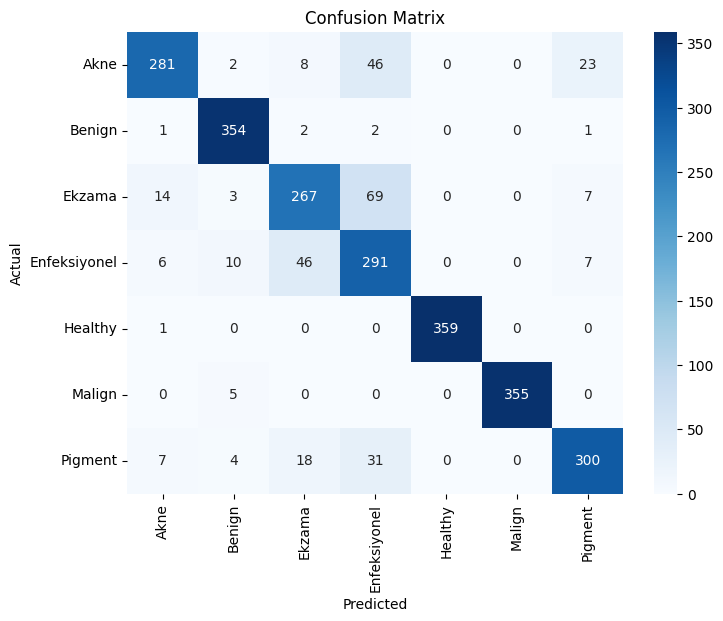

In [61]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [62]:
print("\n📈 Per-Class Accuracy:\n")

for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / np.sum(cm[i])
    print(f"{class_name}: {class_accuracy * 100:.2f}%")



📈 Per-Class Accuracy:

Akne: 78.06%
Benign: 98.33%
Ekzama: 74.17%
Enfeksiyonel: 80.83%
Healthy: 99.72%
Malign: 98.61%
Pigment: 83.33%


In [63]:
roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr')
print(f"\n📊 Overall ROC-AUC: {roc_auc:.4f}")



📊 Overall ROC-AUC: 0.9829


In [64]:
malign_index = class_names.index("Malign")

malign_recall = cm[malign_index, malign_index] / np.sum(cm[malign_index])

print(f"\n🚨 Malign Recall (Sensitivity): {malign_recall * 100:.2f}%")



🚨 Malign Recall (Sensitivity): 98.61%


### updated script

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================
# CONFIG
# =========================
BASE_PATH = r"E:\Final Project\Final_Dataset\skin\stage2_disease_classification"
WEIGHTS_PATH = "skin7_best_weights.h5"
FINAL_MODEL_PATH = "skin7_best_model.keras"

IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 18
AUTOTUNE = tf.data.AUTOTUNE

# =========================
# LOAD DATA
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# =========================
# AUGMENTATION
# =========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.15),
    tf.keras.layers.RandomContrast(0.15),
])

train_ds = train_ds.map(
    lambda x, y: (
        data_augmentation(preprocess_input(x), training=True),
        tf.one_hot(y, depth=num_classes)
    ),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (
        preprocess_input(x),
        tf.one_hot(y, depth=num_classes)
    ),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# =========================
# BUILD MODEL
# =========================
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

base_model.trainable = True

# Unfreeze more layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=(256, 256, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# =========================
# FOCAL LOSS
# =========================
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(
    gamma=2.0
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

# =========================
# RESUME TRAINING
# =========================
if os.path.exists(WEIGHTS_PATH):
    print("Loading previous weights...")
    model.load_weights(WEIGHTS_PATH)

# =========================
# CALLBACKS
# =========================
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    WEIGHTS_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# SAVE FINAL MODEL
# =========================
model.save(FINAL_MODEL_PATH)
print("Improved model saved successfully.")


### Automated evaluation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf

# =========================
# LOAD MODEL
# =========================
model = tf.keras.models.load_model("skin7_best_model.keras")

# =========================
# LOAD TEST DATA
# =========================
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"E:\Final Project\Final_Dataset\skin\stage2_disease_classification\test",
    image_size=(256,256),
    batch_size=8,
    shuffle=False
)

class_names = test_ds.class_names
num_classes = len(class_names)

test_ds_processed = test_ds.map(
    lambda x, y: (tf.keras.applications.efficientnet.preprocess_input(x), y)
)

# =========================
# PREDICTIONS
# =========================
y_true = []
y_pred = []

for images, labels in test_ds_processed:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# =========================
# CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================
# PER CLASS ACCURACY
# =========================
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy):
    print(f"{class_names[i]}: {acc*100:.2f}%")

# =========================
# MALIGN RECALL ANALYSIS
# =========================
malign_index = class_names.index("Malign")
malign_recall = per_class_accuracy[malign_index]
print(f"\nMalign Recall: {malign_recall*100:.2f}%")


In [ ]:
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i,j] > 20:
            print(f"{class_names[i]} misclassified as {class_names[j]}: {cm[i,j]} times")
